# Customer Churn Dynamics: Exploratory Data Analysis

## Objective
This notebook performs exploratory data analysis (EDA) on the Telco Customer Churn dataset. The goal is to understand the structure of the data, identify important feature patterns, clean the dataset, and explore how customer attributes relate to churn.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Dataset Loading
This section loads the Telco Customer Churn dataset from the zip file and displays the first few rows to confirm that the file was read correctly.

In [28]:
zip_path = "archive.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files in zip:", z.namelist())
    with z.open("WA_Fn-UseC_-Telco-Customer-Churn.csv") as f:
        df = pd.read_csv(f)

df.head()

Files in zip: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

df.head()

Shape of dataset: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [31]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Initial Structure Notes

- Number of rows: 7043
- Number of columns: 21  
- Target variable: Churn  
- Main categorical features: gender, Partner, Dependents, PhoneService, InternetService, Contract, PaymentMethod, PaperlessBilling  
- Main numerical features: tenure, MonthlyCharges, TotalCharges, SeniorCitizen  

- Initial observations:
  The dataset contains a mix of categorical and numerical features, with most columns being categorical. The target variable "Churn" is binary, indicating whether a customer has left the service.

## Data Cleaning
The `TotalCharges` column may contain blank strings, so it is converted to numeric values. Any rows that become missing after conversion are removed.

In [32]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [33]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [34]:
rows_before = df.shape[0]
df = df.dropna()
rows_after = df.shape[0]

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Rows removed:", rows_before - rows_after)
print("Shape after dropping missing values:", df.shape)

Rows before cleaning: 7043
Rows after cleaning: 7032
Rows removed: 11
Shape after dropping missing values: (7032, 21)


## Data Cleaning Notes

- Column cleaned: TotalCharges  
- Why cleaning was needed:
  The column was stored as an object (string) and contained non-numeric values that prevented proper analysis.  
- Number of missing values found: 11 
- Rows removed: 11 
- Final dataset shape after cleaning: (7032, 21)

- Comments:
  The number of removed rows is very small relative to the dataset size, so data loss is minimal and does not significantly impact analysis.

## Descriptive Statistics
This section summarizes the main numerical columns and checks the distribution of the target variable.

In [35]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [36]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [ ]:
(df['Churn'].value_counts(normalize=True) * 100).round(2)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

## Target Variable: Churn

- Number of churned customers: 1869 
- Number of retained customers: 5163  
- Percentage churned: 26.58% 
- Percentage retained: 73.42%

- Initial interpretation:
  The dataset is moderately imbalanced, with a significantly higher number of retained customers compared to churned customers. This imbalance should be considered when evaluating predictive models.

## Numeric Feature Distributions
The following histograms show the distribution of the main numeric variables.

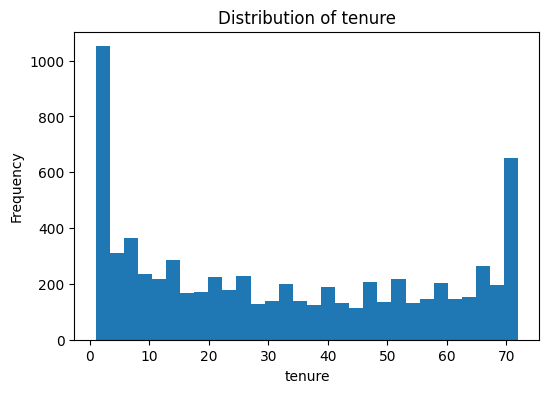

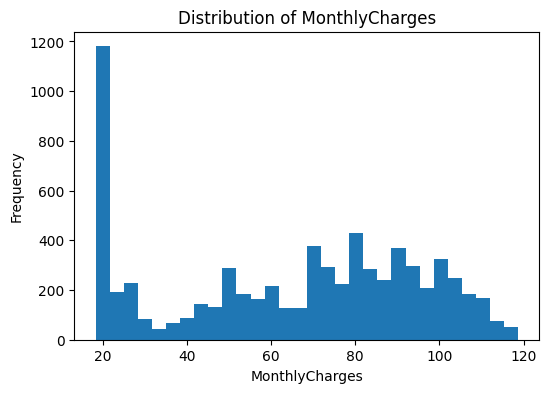

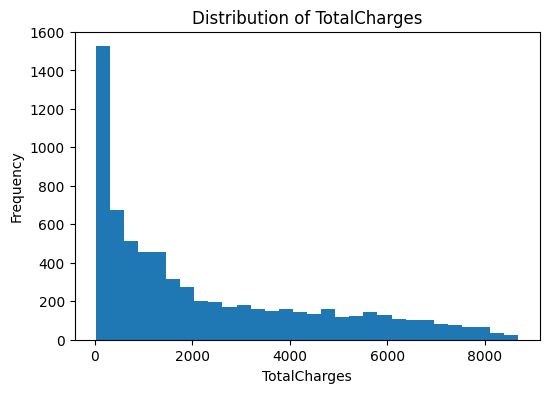

In [ ]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Numeric Feature Distributions

### tenure
- Shape of distribution:
  Right-skewed with a large concentration at very low tenure values.
- Low / medium / high concentration:
  Many customers have very short tenure, with another noticeable concentration at high tenure values.
  
- Any unusual pattern:
  There appears to be a spike at both very low and very high tenure, suggesting two distinct customer groups (new vs long-term).

### MonthlyCharges
- Shape of distribution:
  Fairly spread out with multiple peaks.
- Spread:
  Values range from about 18 to 118.

- Any unusual pattern:
  There are clusters of customers around mid-to-high charge ranges, indicating different pricing tiers.

### TotalCharges
- Shape of distribution:
  Strongly right-skewed.
- Spread:
  Wide range from very low to very high values.

- Any unusual pattern:
  Many customers have low total charges, which aligns with short tenure customers.

## Categorical Feature Summaries
This section prints value counts for selected categorical features.

In [ ]:
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'InternetService', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'Churn'
]

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for gender:
gender
Male      3549
Female    3483
Name: count, dtype: int64

Value counts for SeniorCitizen:
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

Value counts for Partner:
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Value counts for Dependents:
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

Value counts for PhoneService:
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

Value counts for InternetService:
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

Value counts for Contract:
Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

Value counts for PaperlessBilling:
PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64

Value counts for PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)   

## Categorical Feature Notes

### gender
- Main categories: Male, Female  
- Balance between groups:
  Almost perfectly balanced.

- Comments:
  Gender does not appear to be a differentiating factor in the dataset.

### SeniorCitizen
- Main categories: 0 (non-senior), 1 (senior)  

- Comments:
  Majority of customers are not senior citizens.

### Partner / Dependents

- Comments:
  More customers do not have dependents, while partner status is more balanced.

### InternetService
- Main categories: Fiber optic, DSL, No  

- Comments:
  Fiber optic and DSL dominate, with fewer customers having no internet service.

### Contract
- Main categories: Month-to-month, One year, Two year  

- Comments:
  Month-to-month contracts are the most common.

### PaymentMethod
- Main categories: Electronic check, Mailed check, Bank transfer, Credit card  

- Comments:
  Electronic check is the most commonly used method.


## Churn-Focused EDA
These tables and bar charts compare churn rates across important customer categories.

In [40]:
churn_by_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
churn_by_contract.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


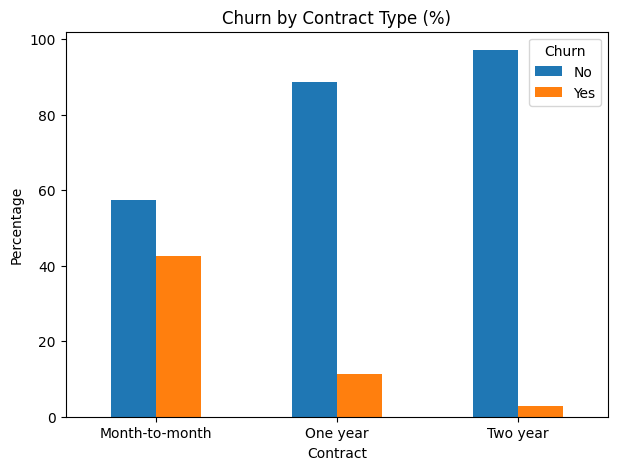

In [41]:
churn_by_contract.plot(kind='bar', figsize=(7,5))
plt.title('Churn by Contract Type (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

In [42]:
churn_by_internet = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
churn_by_internet.round(2)

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


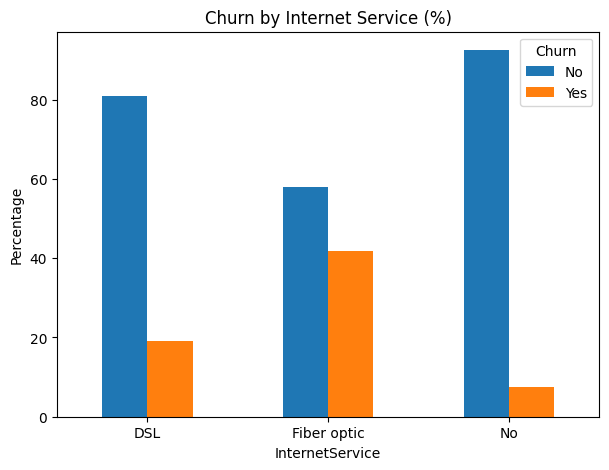

In [43]:
churn_by_internet.plot(kind='bar', figsize=(7,5))
plt.title('Churn by Internet Service (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

In [44]:
churn_by_payment = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
churn_by_payment.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


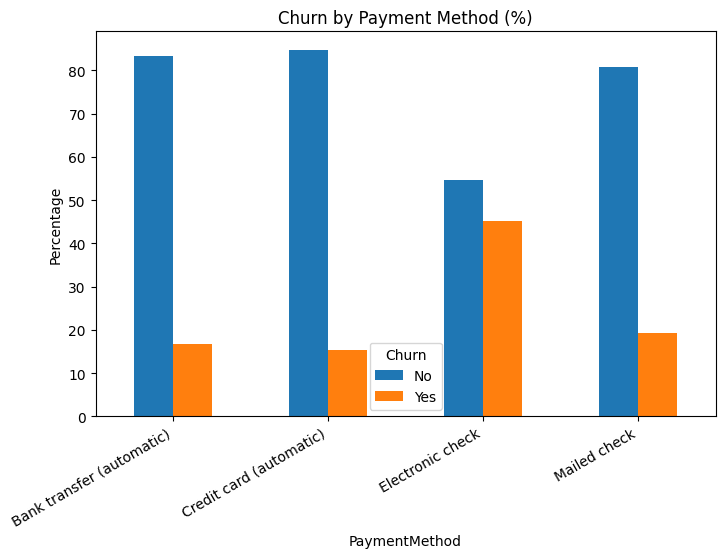

In [45]:
churn_by_payment.plot(kind='bar', figsize=(8,5))
plt.title('Churn by Payment Method (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=30, ha='right')
plt.show()

In [46]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'],
    include_lowest=True
)

churn_by_tenure = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100
churn_by_tenure.round(2)

Churn,No,Yes
TenureGroup,,
0-12 months,52.32,47.68
13-24 months,71.29,28.71
25-48 months,79.61,20.39
49-72 months,90.49,9.51


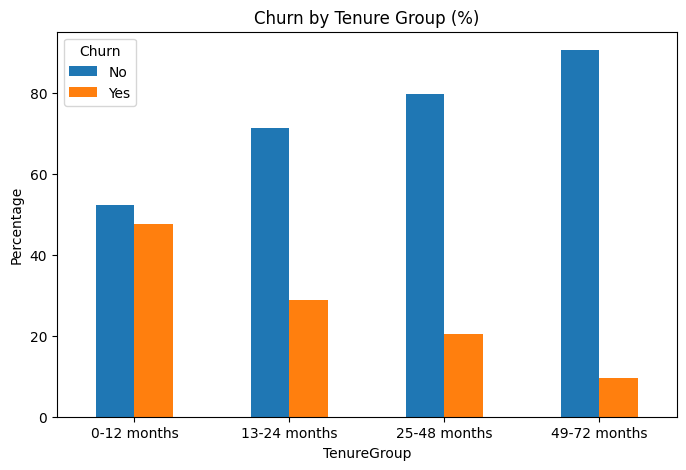

In [47]:
churn_by_tenure.plot(kind='bar', figsize=(8,5))
plt.title('Churn by Tenure Group (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

## Churn Pattern Notes

### Churn by Contract
- Highest churn: Month-to-month (~42.71%) 
- Lowest churn: Two year (~2.85%) 

- Interpretation:
  Customers with shorter contracts are far more likely to churn, while long-term contracts significantly reduce churn.

### Churn by Internet Service
- Most likely to churn: Fiber optic (~41.89%) 

- Interpretation:
  Customers using fiber optic service show higher churn rates, possibly due to cost or service expectations.

### Churn by Payment Method
- Pattern:
  Electronic check users have the highest churn (~45.29%) 

- Interpretation:
  Payment method may be linked to customer stability, with automatic payments associated with lower churn.

### Churn by Tenure Group
- Highest churn: 0-12 months (~47.68%) 
- Lowest churn: 49-72 months (~9.51%) 

- What this suggests:
  New customers are much more likely to leave, while long-term customers are significantly more stable.

## Numeric Features vs Churn
Boxplots are used to compare churned and retained customers for key numeric features.

C:\Users\dolly\AppData\Local\Temp\ipykernel_22288\683062052.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


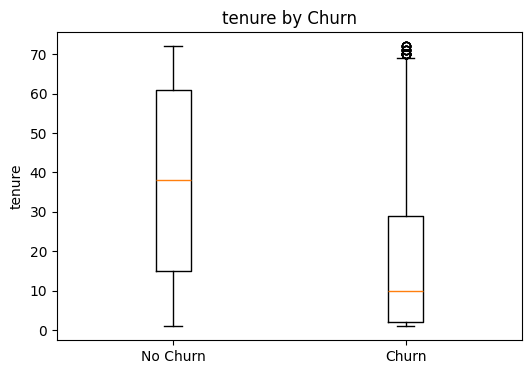

C:\Users\dolly\AppData\Local\Temp\ipykernel_22288\683062052.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


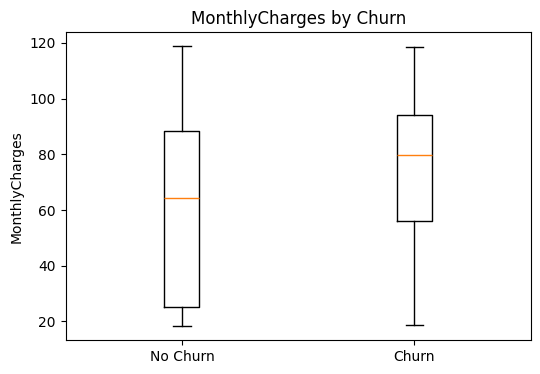

C:\Users\dolly\AppData\Local\Temp\ipykernel_22288\683062052.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


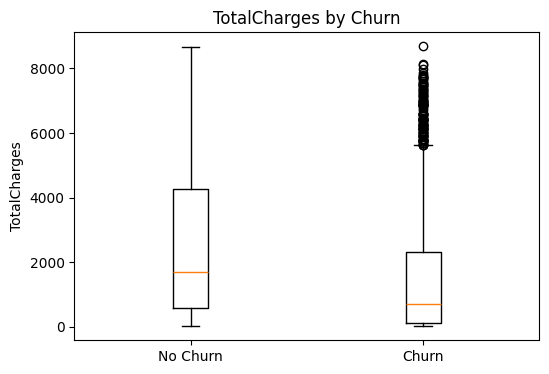

In [48]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    plt.figure(figsize=(6,4))
    plt.boxplot(
        [df[df['Churn']=='No'][col], df[df['Churn']=='Yes'][col]],
        labels=['No Churn', 'Churn']
    )
    plt.title(f'{col} by Churn')
    plt.ylabel(col)
    plt.show()

## Numeric Features vs Churn

### tenure vs Churn
- Churned customers tend to have lower tenure.

- Interpretation:
  Customers who leave the service are typically newer, reinforcing the lifecycle effect.

### MonthlyCharges vs Churn
- Churned customers tend to have slightly higher monthly charges.

- Interpretation:
  Higher pricing may contribute to dissatisfaction and increased churn.

### TotalCharges vs Churn
- Customers who do not churn tend to have higher total charges.

- Interpretation:
  This reflects longer tenure, as customers who stay longer accumulate higher total charges.

## Correlation Analysis
A simple correlation matrix is included for the numeric variables.

In [49]:
numeric_df = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']]
corr = numeric_df.corr()
corr.round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.00,0.02,0.22,0.10
tenure,0.02,1.00,0.25,0.83
MonthlyCharges,0.22,0.25,1.00,0.65
TotalCharges,0.10,0.83,0.65,1.00


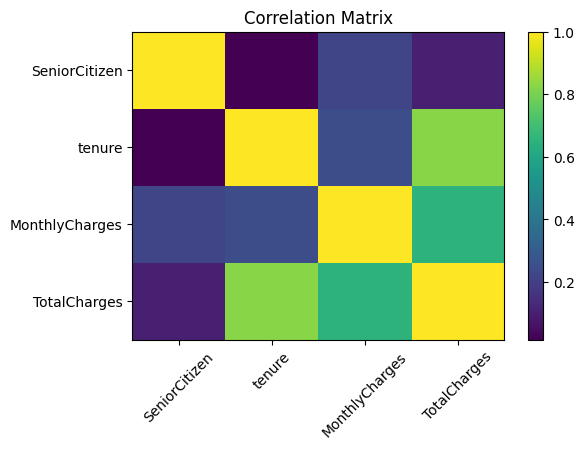

In [50]:
plt.figure(figsize=(6,4))
plt.imshow(corr, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

## Correlation Notes

- Strongest positive relationship:
  tenure and TotalCharges (~0.83) 
- Strongest negative relationship:
  No strong negative correlations observed.
- Closely related variables:
  TotalCharges is strongly related to tenure and moderately related to MonthlyCharges.
  
- Comments:
  The strong relationship between tenure and TotalCharges is expected, as total charges accumulate over time.

## EDA Summary

Based on the exploratory data analysis, several important patterns were identified:

- The dataset contains 7032 cleaned records with a mix of categorical and numerical features.  
- The target variable is Churn, indicating whether a customer has left the service.  
- The most important cleaning step was converting TotalCharges to numeric and removing invalid entries.  

- Customers with month-to-month contracts and short tenure appear more likely to churn.  
- Customers with long-term contracts and higher tenure appear less likely to churn.  

- Tenure shows a strong inverse relationship with churn, meaning newer customers are more likely to leave.  
- Monthly charges show a positive relationship with churn, where higher charges are associated with higher churn.  
- Contract type has a significant impact, with long-term contracts greatly reducing churn rates.  

- These findings suggest that customer retention strategies should focus on early-stage customers, pricing structures, and encouraging long-term contract commitments.

In [51]:
# Final quick peek at cleaned data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months
